**Handling Missing Values -- Random Sample Imputation**

In this technique we impute the missing values with values picked randomly from the column we are working on.

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [28]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [29]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [32]:
X_train['Age_Imputed'] = X_train['Age']
X_test['Age_Imputed'] = X_test['Age']

In [33]:
X_train.tail()

,Age,Fare,Age_Imputed
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0
102,21.0,77.2875,21.0


In [34]:
X_train['Age_Imputed'][X_train['Age_Imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_Imputed'][X_test['Age_Imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/var/folders/fp/5knn2n7d2yb5ll095thsygkr0000gn/T/ipykernel_8388/2836983312.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_Imputed'][X_train['Age_Imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().s

In [35]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([21.  , 28.  , 31.  , 28.  , 47.  , 30.  , 42.  ,  8.  , 38.  ,
       36.  , 17.  , 22.  , 16.  , 24.  , 28.  , 36.  , 47.  , 24.  ,
       52.  , 59.  , 35.  , 62.  , 46.  , 25.  , 31.  , 44.  ,  8.  ,
        3.  , 35.  , 22.  , 18.  , 33.  , 18.  , 28.  , 32.5 , 29.  ,
       19.  , 16.  , 20.  , 45.  , 30.  , 50.  , 57.  , 41.  , 24.  ,
       65.  , 19.  , 32.  , 30.  , 59.  ,  3.  ,  2.  , 34.  , 26.  ,
        0.75, 28.  , 58.  , 26.  , 29.  , 54.  , 27.  , 54.  , 50.  ,
       25.  , 60.  , 74.  , 36.  , 33.  , 25.  , 15.  , 23.  , 20.  ,
       23.  ,  1.  , 50.  , 26.  , 32.  , 30.  , 42.  , 21.  , 40.  ,
       21.  , 35.  , 46.  , 18.  ,  3.  , 54.  , 17.  , 21.  , 28.  ,
       17.  , 18.  , 34.5 ,  3.  , 25.  , 32.5 , 18.  , 51.  , 18.  ,
       47.  , 34.  , 24.  , 45.5 , 24.  ,  8.  , 20.  , 27.  , 33.  ,
        5.  ,  9.  , 17.  , 31.  , 26.  , 36.  , 20.  , 35.  , 49.  ,
       35.  , 16.  , 36.  , 25.  , 43.  , 31.  , 23.  , 24.  ,  0.75,
       31.  , 41.  ,

In [36]:
X_train['Age'].isnull().sum()

np.int64(140)

In [37]:
X_train

,Age,Fare,Age_Imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,29.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


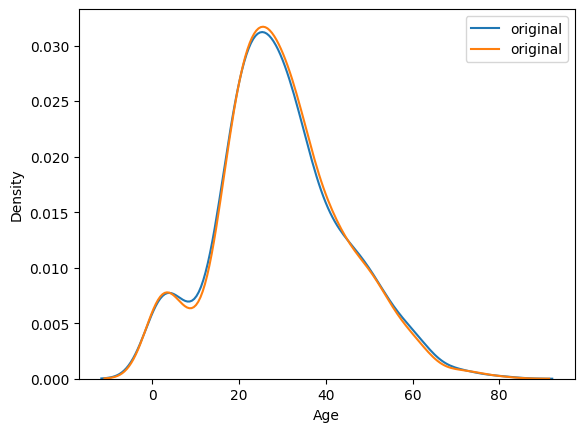

In [38]:
sns.kdeplot(X_train['Age'], label='original')
sns.kdeplot(X_train['Age_Imputed'], label='original')

plt.legend()
plt.show()

In [39]:
print('Original var variance', X_train['Age'].var())
print('Original var variance', X_train['Age_Imputed'].var())

Original var variance 210.2517072477435
Original var variance 203.64871828805764


In [40]:
X_train[['Fare', 'Age', 'Age_Imputed']].cov()

,Fare,Age,Age_Imputed
Fare,2700.831981,71.580633,42.897311
Age,71.580633,210.251707,210.251707
Age_Imputed,42.897311,210.251707,203.648718


<Axes: >

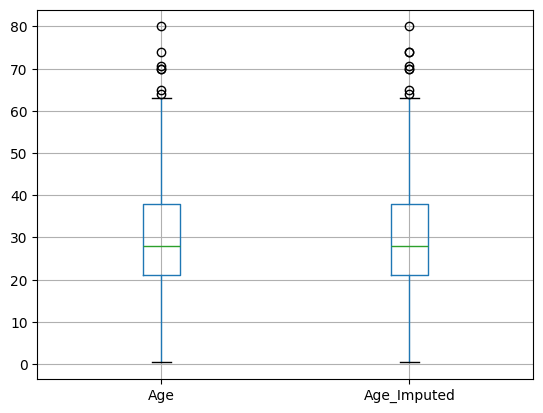

In [41]:
X_train[['Age', 'Age_Imputed']].boxplot()

**Now for categorical data**

In [42]:
data = pd.read_csv('house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [43]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [44]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [45]:
X = data
y = data['SalePrice']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [47]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [48]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
692,Gd,TA,335000,TA,Gd
317,Gd,TA,270000,TA,Gd
392,NaN,TA,106500,TA,NaN
738,NaN,NaN,179000,NaN,NaN
1314,TA,TA,119000,TA,TA


In [51]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/var/folders/fp/5knn2n7d2yb5ll095thsygkr0000gn/T/ipykernel_8388/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_tra

In [52]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [53]:
temp

,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.037671
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [54]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.646465
TA,0.412439,0.543210
Fa,0.040917,0.050505
Po,0.027823,0.038159
Ex,0.024550,0.032548


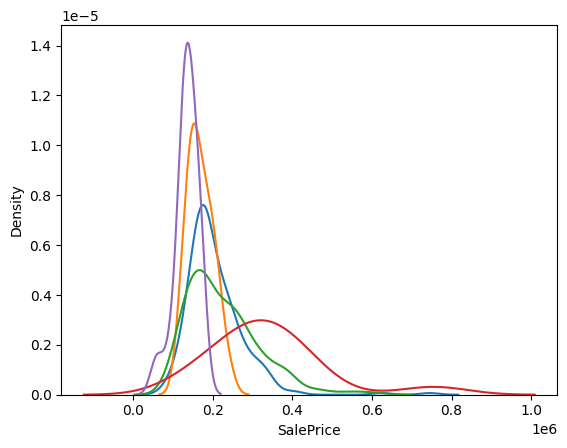

In [56]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()